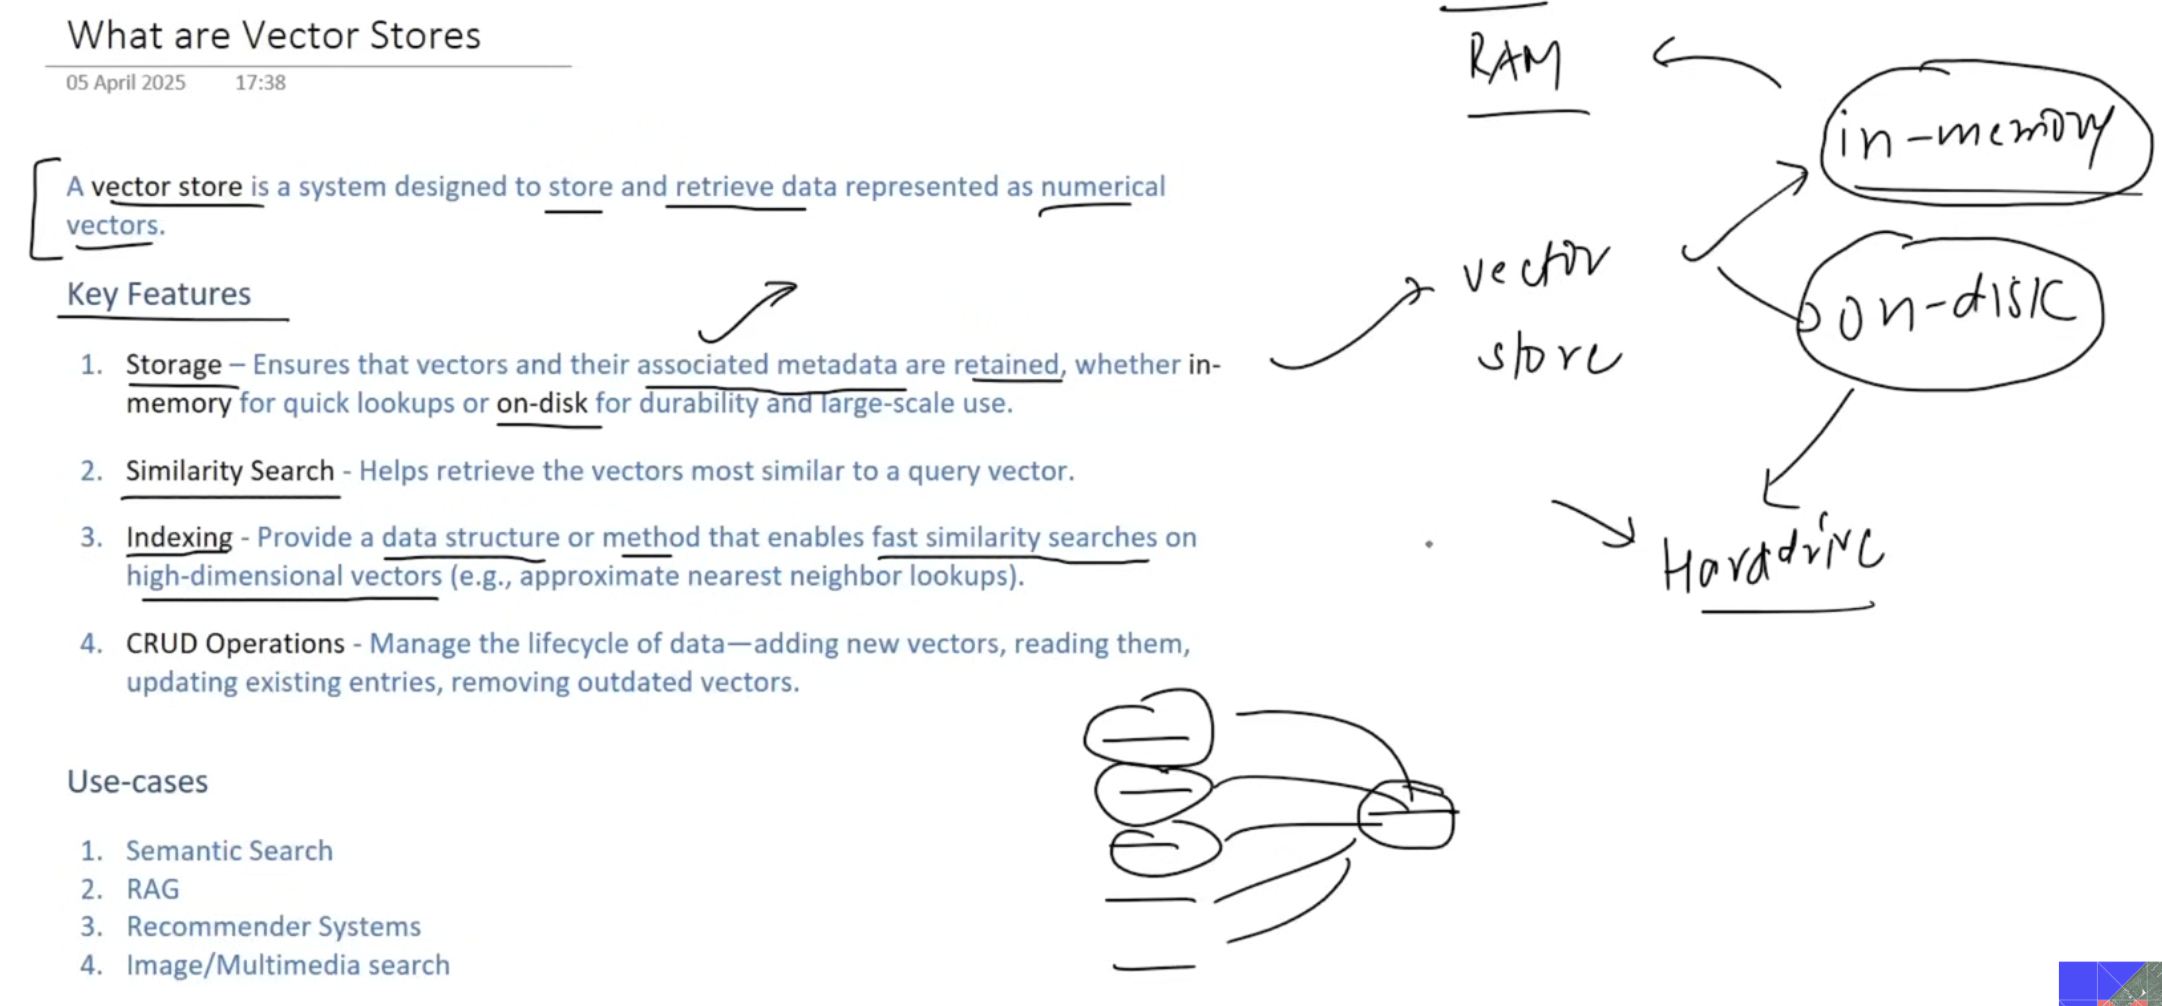

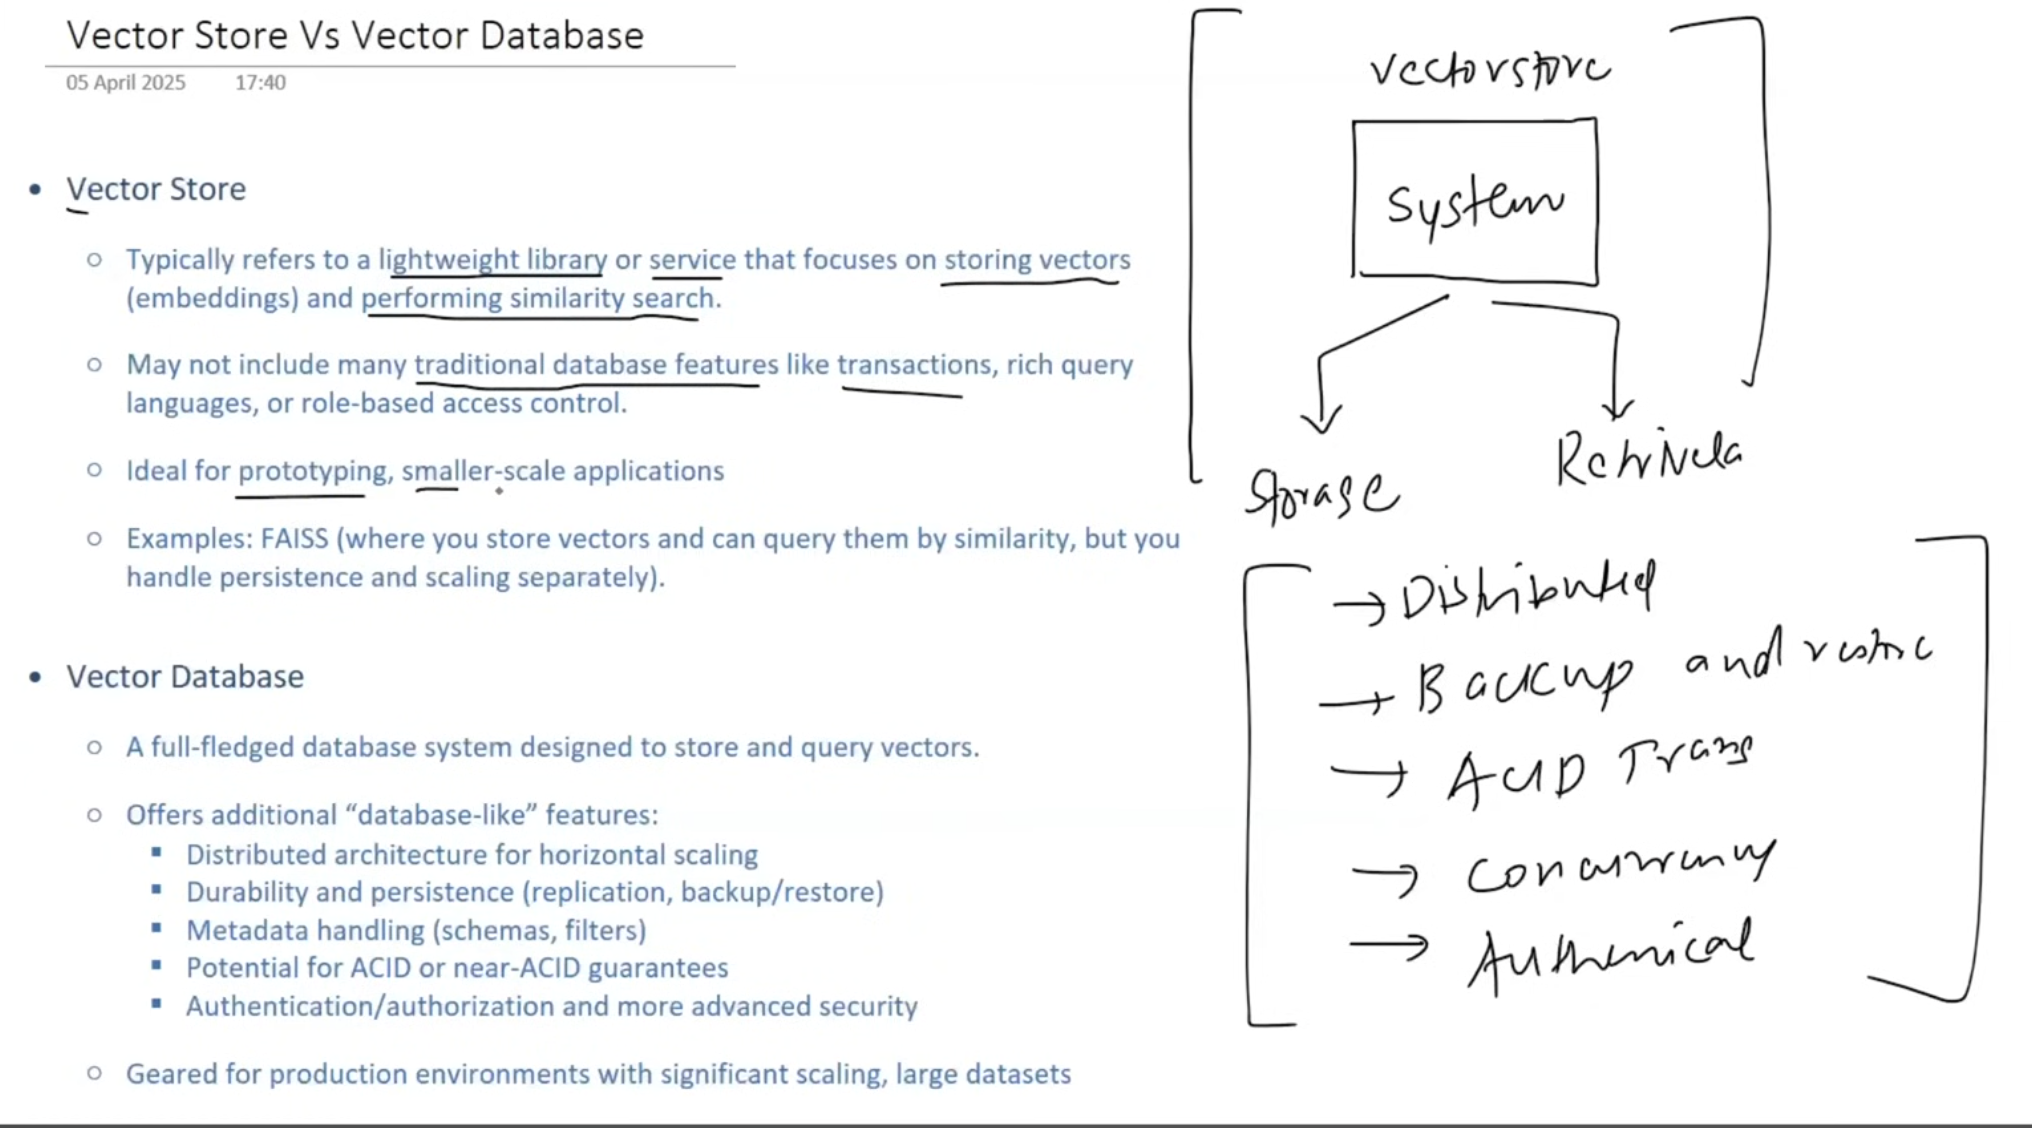

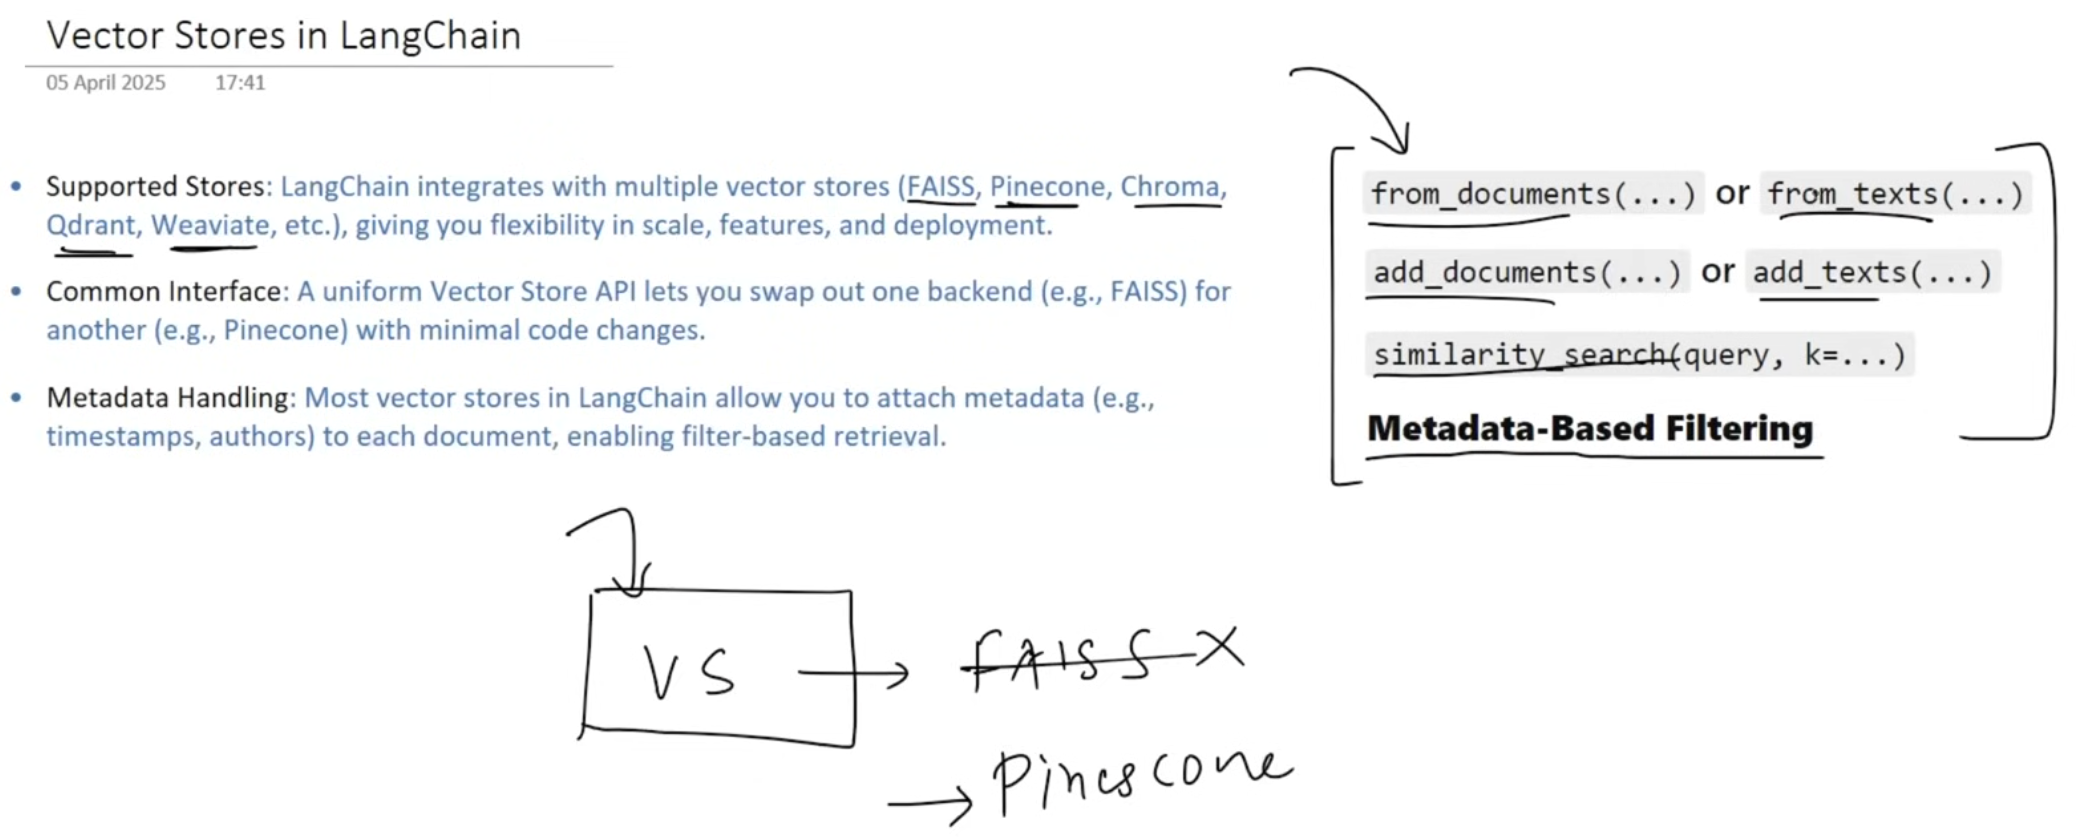

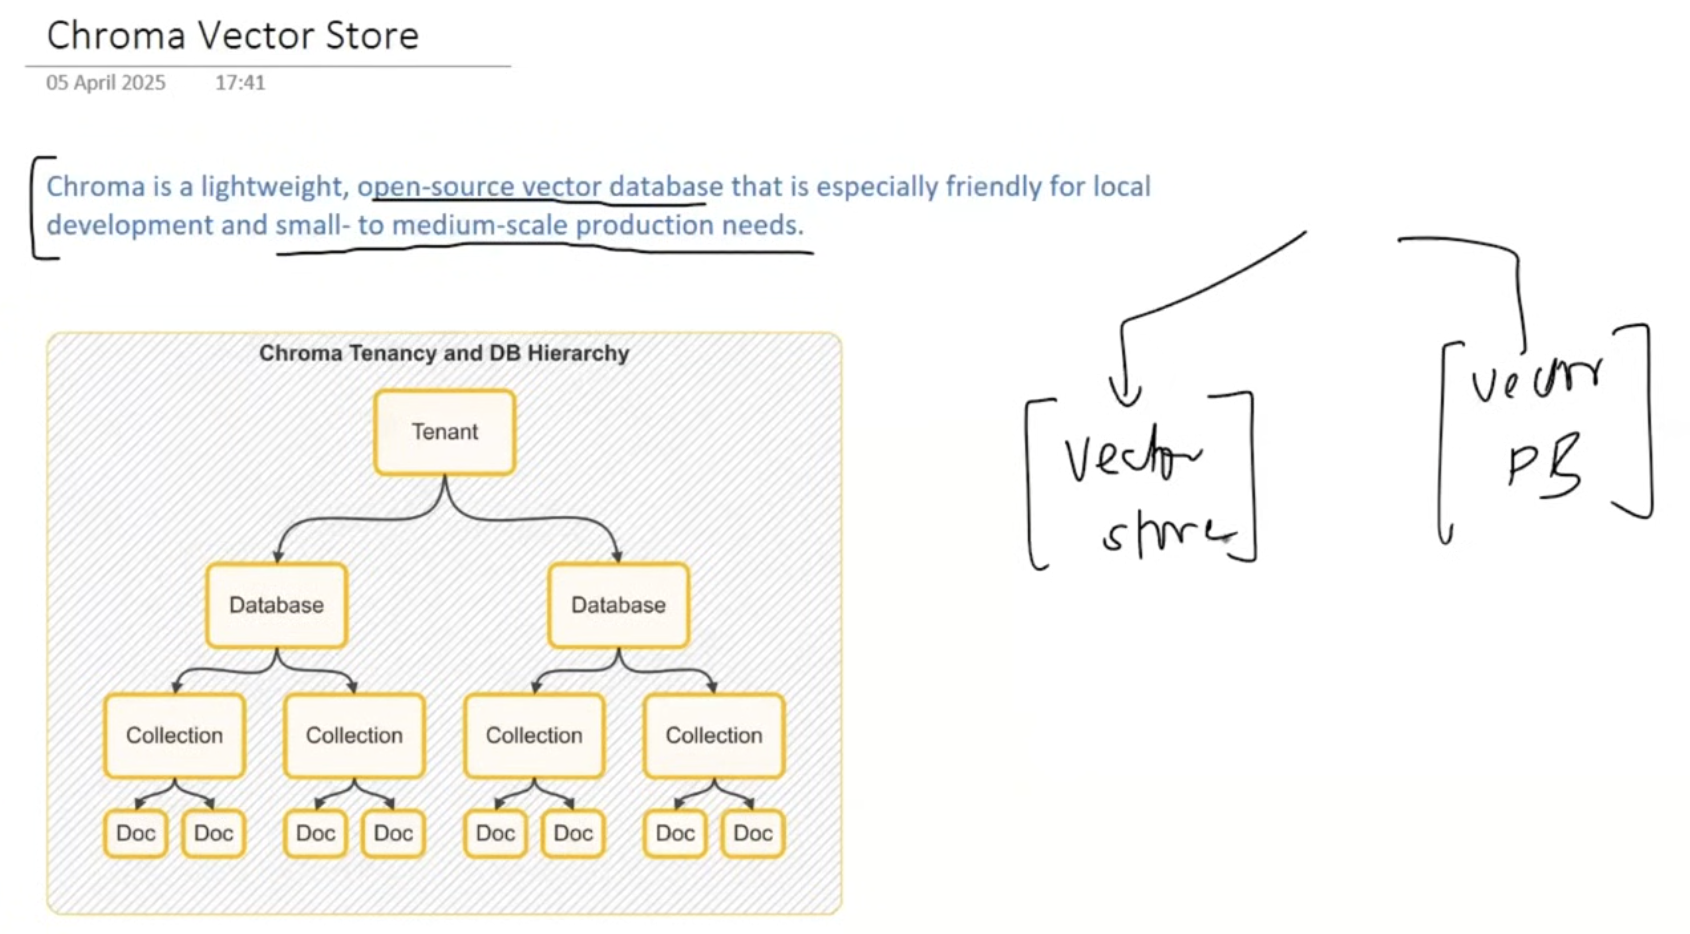

In [1]:
%pip install langchain chromadb openai tiktoken pypdf langchain_openai langchain-community

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached importlib_metadata-8.6.1-py3-none-any.whl.metadata (4.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 7.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.7 MB/s eta 0:00:00a 0:00:01
Using cached importlib_metadata-8.6.1-py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 860.2 kB/s eta 0:00:00a 0:00:01
  Created wheel for pypika: filename=pypika-0.48.9-py2.py3-none-any.whl size=53801 sha256=4c1224c047dfe58ef495fe1cd66e3a43f87581f79a58cf4e37adeef1330208eb
  Stored in directory: /Users/sanghvi/Library/Caches/pip/wheels/d5/3d/69/8d68d249cd3de2584f226e27fd431d6344f7d70fd856ebd01b
Successfully built pypika
  Attempting uninstall: fastapi
    Found existing installation: fastapi 0.115.5
    Uninstalling fastapi-0.115.5:
      Successfully uninstalled fastapi-0.115.5
N

In [3]:
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma

embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

In [4]:
from langchain.schema import Document

# Create LangChain documents for IPL players

doc1 = Document(
        page_content="Virat Kohli is one of the most successful and consistent batsmen in IPL history. Known for his aggressive batting style and fitness, he has led the Royal Challengers Bangalore in multiple seasons.",
        metadata={"team": "Royal Challengers Bangalore"}
    )
doc2 = Document(
        page_content="Rohit Sharma is the most successful captain in IPL history, leading Mumbai Indians to five titles. He's known for his calm demeanor and ability to play big innings under pressure.",
        metadata={"team": "Mumbai Indians"}
    )
doc3 = Document(
        page_content="MS Dhoni, famously known as Captain Cool, has led Chennai Super Kings to multiple IPL titles. His finishing skills, wicketkeeping, and leadership are legendary.",
        metadata={"team": "Chennai Super Kings"}
    )
doc4 = Document(
        page_content="Jasprit Bumrah is considered one of the best fast bowlers in T20 cricket. Playing for Mumbai Indians, he is known for his yorkers and death-over expertise.",
        metadata={"team": "Mumbai Indians"}
    )
doc5 = Document(
        page_content="Ravindra Jadeja is a dynamic all-rounder who contributes with both bat and ball. Representing Chennai Super Kings, his quick fielding and match-winning performances make him a key player.",
        metadata={"team": "Chennai Super Kings"}
    )

In [5]:
docs = [doc1, doc2, doc3, doc4, doc5]

In [9]:
vector_store = Chroma(
    embedding_function=embedding_model,
    persist_directory='my_chroma_db',
    collection_name='sample'
)

In [10]:
# add documents
vector_store.add_documents(docs)

['4e8be9cd-a304-4821-bc7f-77dc0b3824b6',
 '9d1b89e8-d3af-4421-bc43-9d943d0eb62b',
 'c65fd35a-f3c6-420c-8c66-f0f4903cdb1a',
 '94102f18-bd67-43fe-998b-748ea7d783a6',
 '3539d1bb-f691-4e4d-896e-22675f923e1c']

In [11]:
# view documents
vector_store.get(include=['embeddings','documents', 'metadatas'])

{'ids': ['4e8be9cd-a304-4821-bc7f-77dc0b3824b6',
  '9d1b89e8-d3af-4421-bc43-9d943d0eb62b',
  'c65fd35a-f3c6-420c-8c66-f0f4903cdb1a',
  '94102f18-bd67-43fe-998b-748ea7d783a6',
  '3539d1bb-f691-4e4d-896e-22675f923e1c'],
 'embeddings': array([[ 0.0099472 ,  0.0691433 , -0.05147115, ..., -0.03543335,
          0.01284805,  0.01248287],
        [ 0.00127745,  0.0312985 , -0.0237538 , ..., -0.00518361,
         -0.03280609,  0.02737714],
        [-0.10265917,  0.02650803,  0.02271505, ..., -0.03359751,
         -0.07984945, -0.01507708],
        [ 0.02123396, -0.02468548, -0.04494372, ..., -0.10995813,
          0.00572554,  0.09915375],
        [ 0.01873977,  0.04382844, -0.04304253, ..., -0.07801616,
         -0.0784068 , -0.0030419 ]]),
 'documents': ['Virat Kohli is one of the most successful and consistent batsmen in IPL history. Known for his aggressive batting style and fitness, he has led the Royal Challengers Bangalore in multiple seasons.',
  "Rohit Sharma is the most successful ca

In [15]:
# search documents
vector_store.similarity_search_with_score(
    query='Who among these are a batter?',
    k=2 # number of similar results to return
)

[(Document(metadata={'team': 'Mumbai Indians'}, page_content="Rohit Sharma is the most successful captain in IPL history, leading Mumbai Indians to five titles. He's known for his calm demeanor and ability to play big innings under pressure."),
  1.3784539699554443),
 (Document(metadata={'team': 'Royal Challengers Bangalore'}, page_content='Virat Kohli is one of the most successful and consistent batsmen in IPL history. Known for his aggressive batting style and fitness, he has led the Royal Challengers Bangalore in multiple seasons.'),
  1.4477022886276245)]

In [16]:
# meta-data filtering
vector_store.similarity_search_with_score(
    query="",
    filter={"team": "Chennai Super Kings"}
)

[(Document(metadata={'team': 'Chennai Super Kings'}, page_content='MS Dhoni, famously known as Captain Cool, has led Chennai Super Kings to multiple IPL titles. His finishing skills, wicketkeeping, and leadership are legendary.'),
  1.8436006307601929),
 (Document(metadata={'team': 'Chennai Super Kings'}, page_content='Ravindra Jadeja is a dynamic all-rounder who contributes with both bat and ball. Representing Chennai Super Kings, his quick fielding and match-winning performances make him a key player.'),
  1.890937328338623)]

In [19]:
# update documents
updated_doc1 = Document(
    page_content="Virat Kohli, the former captain of Royal Challengers Bangalore (RCB), is renowned for his aggressive leadership and consistent batting performances. He holds the record for the most runs in IPL history, including multiple centuries in a single season. Despite RCB not winning an IPL title under his captaincy, Kohli's passion and fitness set a benchmark for the league. His ability to chase targets and anchor innings has made him one of the most dependable players in T20 cricket.",
    metadata={"team": "Royal Challengers Bangalore"}
)

vector_store.update_document(document_id='4e8be9cd-a304-4821-bc7f-77dc0b3824b6', document=updated_doc1)

In [20]:
# view documents
vector_store.get(include=['embeddings','documents', 'metadatas'])

{'ids': ['4e8be9cd-a304-4821-bc7f-77dc0b3824b6',
  '9d1b89e8-d3af-4421-bc43-9d943d0eb62b',
  'c65fd35a-f3c6-420c-8c66-f0f4903cdb1a',
  '94102f18-bd67-43fe-998b-748ea7d783a6',
  '3539d1bb-f691-4e4d-896e-22675f923e1c'],
 'embeddings': array([[-0.00233745,  0.05902075, -0.04774041, ..., -0.0726405 ,
          0.00276788, -0.0034409 ],
        [ 0.00127745,  0.0312985 , -0.0237538 , ..., -0.00518361,
         -0.03280609,  0.02737714],
        [-0.10265917,  0.02650803,  0.02271505, ..., -0.03359751,
         -0.07984945, -0.01507708],
        [ 0.02123396, -0.02468548, -0.04494372, ..., -0.10995813,
          0.00572554,  0.09915375],
        [ 0.01873977,  0.04382844, -0.04304253, ..., -0.07801616,
         -0.0784068 , -0.0030419 ]]),
 'documents': ["Virat Kohli, the former captain of Royal Challengers Bangalore (RCB), is renowned for his aggressive leadership and consistent batting performances. He holds the record for the most runs in IPL history, including multiple centuries in a sin

In [21]:
# search documents
vector_store.similarity_search_with_score(
    query='Who among these are a batter?',
    k=2 # number of similar results to return
)

[(Document(metadata={'team': 'Royal Challengers Bangalore'}, page_content="Virat Kohli, the former captain of Royal Challengers Bangalore (RCB), is renowned for his aggressive leadership and consistent batting performances. He holds the record for the most runs in IPL history, including multiple centuries in a single season. Despite RCB not winning an IPL title under his captaincy, Kohli's passion and fitness set a benchmark for the league. His ability to chase targets and anchor innings has made him one of the most dependable players in T20 cricket."),
  1.3608452081680298),
 (Document(metadata={'team': 'Mumbai Indians'}, page_content="Rohit Sharma is the most successful captain in IPL history, leading Mumbai Indians to five titles. He's known for his calm demeanor and ability to play big innings under pressure."),
  1.3784539699554443)]

In [22]:
# delete document
vector_store.delete(ids=['3539d1bb-f691-4e4d-896e-22675f923e1c'])

In [23]:
# view documents
vector_store.get(include=['embeddings','documents', 'metadatas'])

{'ids': ['4e8be9cd-a304-4821-bc7f-77dc0b3824b6',
  '9d1b89e8-d3af-4421-bc43-9d943d0eb62b',
  'c65fd35a-f3c6-420c-8c66-f0f4903cdb1a',
  '94102f18-bd67-43fe-998b-748ea7d783a6'],
 'embeddings': array([[-0.00233745,  0.05902075, -0.04774041, ..., -0.0726405 ,
          0.00276788, -0.0034409 ],
        [ 0.00127745,  0.0312985 , -0.0237538 , ..., -0.00518361,
         -0.03280609,  0.02737714],
        [-0.10265917,  0.02650803,  0.02271505, ..., -0.03359751,
         -0.07984945, -0.01507708],
        [ 0.02123396, -0.02468548, -0.04494372, ..., -0.10995813,
          0.00572554,  0.09915375]]),
 'documents': ["Virat Kohli, the former captain of Royal Challengers Bangalore (RCB), is renowned for his aggressive leadership and consistent batting performances. He holds the record for the most runs in IPL history, including multiple centuries in a single season. Despite RCB not winning an IPL title under his captaincy, Kohli's passion and fitness set a benchmark for the league. His ability to